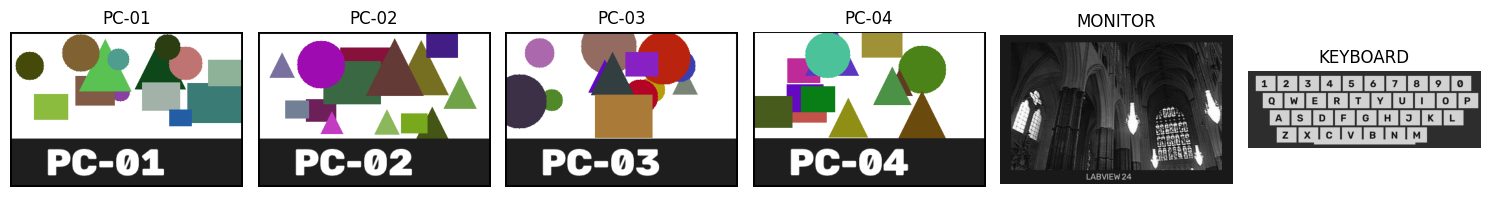

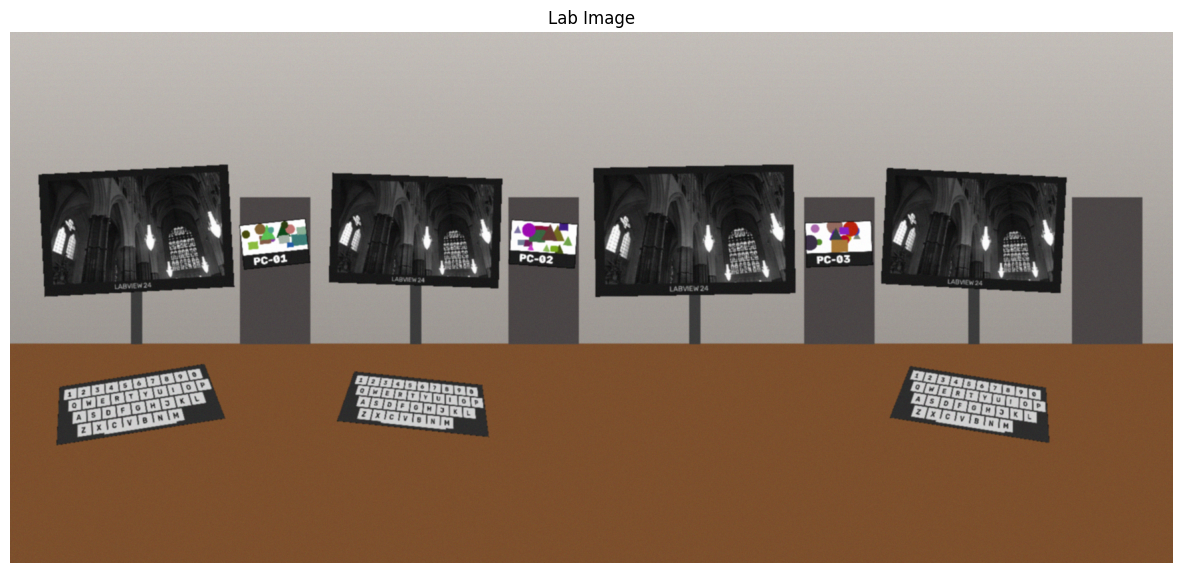

Lab image keypoints: 3735
PC-01 keypoints: 114
PC-02 keypoints: 130
PC-03 keypoints: 116
PC-04 keypoints: 135
MONITOR keypoints: 641
KEYBOARD keypoints: 600


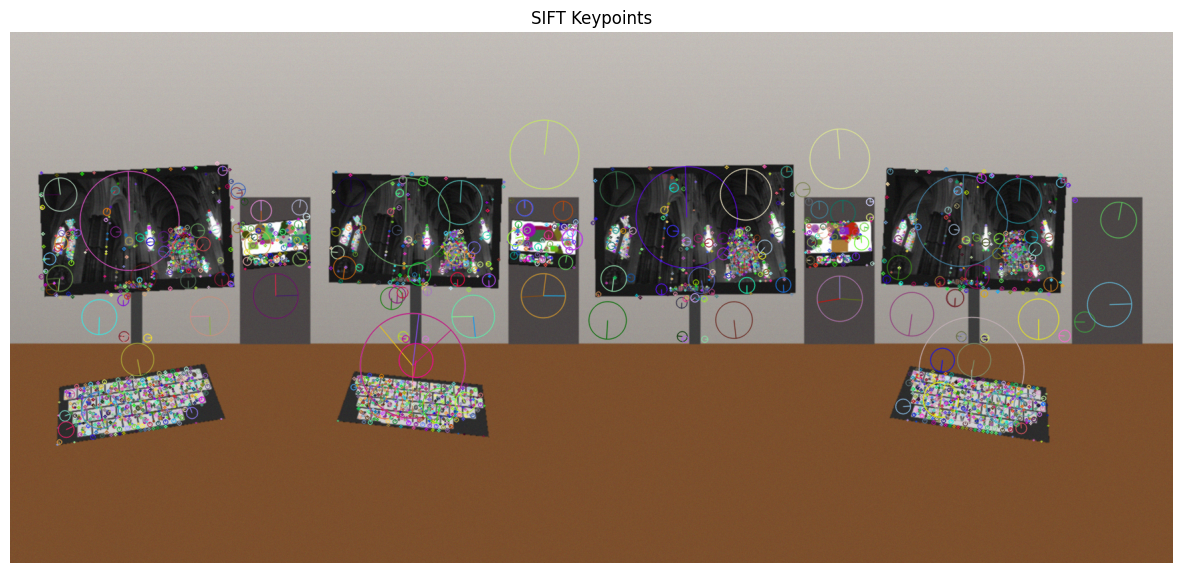

PC-01 found: 1
PC-02 found: 1
PC-03 found: 1
PC-04 found: 0
MONITOR found: 4
KEYBOARD found: 3


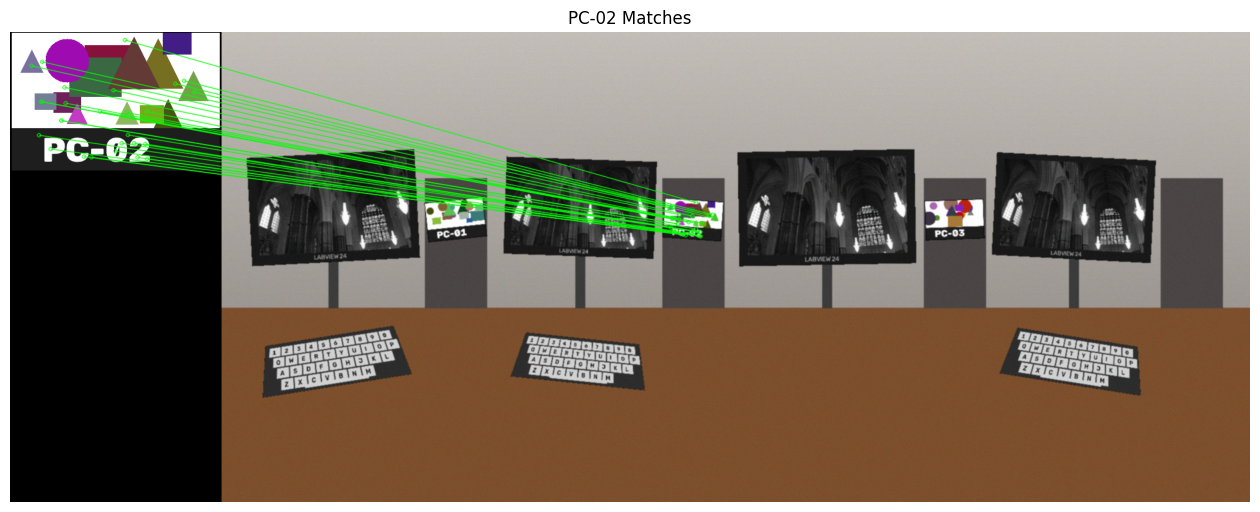

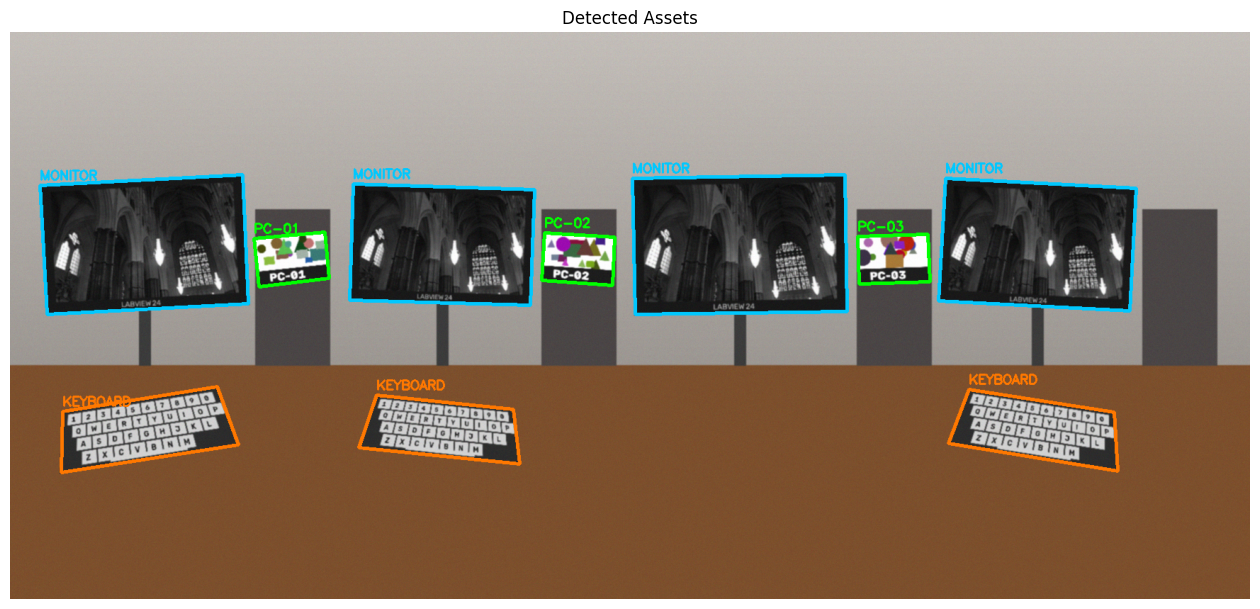


Inventory:
PC-01 : monitor = 1  keyboard = 1  -> ok
PC-02 : monitor = 1  keyboard = 1  -> ok
PC-03 : monitor = 1  keyboard = 0  -> keyboard missing
PC-04 : not found in lab
Items without PC tag: ['MONITOR', 'KEYBOARD']


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the lab image
scene = cv2.imread("lab_scene_assets.png")
if scene is None:
    print("Image not found, check the path")

# Read the database images (one tag for each PC + monitor + keyboard)
names = ["PC-01", "PC-02", "PC-03", "PC-04", "MONITOR", "KEYBOARD"]
database = {}
for name in names:
    database[name] = cv2.imread(name + ".png")

# Show database images
plt.figure(figsize=(15, 4))
for i in range(len(names)):
    plt.subplot(1, 6, i + 1)
    plt.imshow(cv2.cvtColor(database[names[i]], cv2.COLOR_BGR2RGB))
    plt.title(names[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Show lab image
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
plt.title("Lab Image")
plt.axis("off")
plt.show()

# Create SIFT detector
sift = cv2.SIFT_create()

# Keypoints and descriptors of lab image
scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
kp_scene, des_scene = sift.detectAndCompute(scene_gray, None)
print("Lab image keypoints:", len(kp_scene))

# Keypoints and descriptors of database images
kp_db = {}
des_db = {}
for name in names:
    gray = cv2.cvtColor(database[name], cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(gray, None)
    kp_db[name] = kp
    des_db[name] = des
    print(name, "keypoints:", len(kp))

# Draw keypoints on lab image
kp_image = cv2.drawKeypoints(scene, kp_scene, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(kp_image, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis("off")
plt.show()

# Brute force matcher
bf = cv2.BFMatcher(cv2.NORM_L2)

# find an object in the lab image
# there are many monitors and keyboards, so after finding one
# remove its keypoints and search again
def find_object(name, max_count):
    kp1 = kp_db[name]
    des1 = des_db[name]
    h, w = database[name].shape[:2]

    available = np.ones(len(kp_scene), bool)
    found = []

    for t in range(max_count):
        index = np.where(available)[0]
        matches = bf.knnMatch(des1, des_scene[index], k=2)

        # Lowe's ratio test
        good = []
        for m in matches:
            if len(m) == 2 and m[0].distance < 0.75 * m[1].distance:
                good.append(m[0])

        if len(good) < 12:
            break

        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_scene[index[m.trainIdx]].pt for m in good]).reshape(-1, 1, 2)

        # Homography with RANSAC
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        if M is None or mask.sum() < 12:
            break

        # corners of the object in lab image
        corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
        box = cv2.perspectiveTransform(corners, M).reshape(-1, 2)

        # check if box shape is ok
        if cv2.isContourConvex(box.astype(np.int32)) == False or cv2.contourArea(box) < 1500:
            break

        found.append(box)

        # remove keypoints inside this box
        center = box.mean(axis=0)
        bigger_box = (box - center) * 1.1 + center
        for k in index:
            if cv2.pointPolygonTest(bigger_box.astype(np.float32), kp_scene[k].pt, False) >= 0:
                available[k] = False

    return found

# Search every object
results = {}
for name in names:
    if name.startswith("PC"):
        results[name] = find_object(name, 1)
    else:
        results[name] = find_object(name, 6)
    print(name, "found:", len(results[name]))

# Show matches for one tag
kp1 = kp_db["PC-02"]
des1 = des_db["PC-02"]
matches = bf.knnMatch(des1, des_scene, k=2)
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)
src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

match_image = cv2.drawMatches(database["PC-02"], kp1, scene, kp_scene, good, None,
                              matchColor=(0, 255, 0), matchesMask=mask.ravel().tolist(), flags=2)
plt.figure(figsize=(16, 7))
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title("PC-02 Matches")
plt.axis("off")
plt.show()

# Draw all detected objects
result = scene.copy()
for name in names:
    if name.startswith("PC"):
        color = (0, 255, 0)
    elif name == "MONITOR":
        color = (255, 200, 0)
    else:
        color = (0, 120, 255)
    for box in results[name]:
        cv2.polylines(result, [box.astype(np.int32)], True, color, 3)
        cv2.putText(result, name, (int(box[0][0]), int(box[0][1]) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Assets")
plt.axis("off")
plt.show()

# Inventory
# monitor and keyboard belong to the PC tower on their right side
inventory = {}
for name in ["PC-01", "PC-02", "PC-03", "PC-04"]:
    if len(results[name]) > 0:
        inventory[name] = {"MONITOR": 0, "KEYBOARD": 0}

no_owner = []
for item in ["MONITOR", "KEYBOARD"]:
    for box in results[item]:
        item_x = box[:, 0].mean()
        owner = None
        closest = 300
        for pc in inventory:
            tag_x = results[pc][0][:, 0].mean()
            distance = tag_x - item_x
            if distance > 0 and distance < closest:
                closest = distance
                owner = pc
        if owner is None:
            no_owner.append(item)
        else:
            inventory[owner][item] += 1

print()
print("Inventory:")
for pc in ["PC-01", "PC-02", "PC-03", "PC-04"]:
    if pc not in inventory:
        print(pc, ": not found in lab")
    else:
        monitors = inventory[pc]["MONITOR"]
        keyboards = inventory[pc]["KEYBOARD"]
        status = "ok"
        if monitors == 0:
            status = "monitor missing"
        if keyboards == 0:
            status = "keyboard missing"
        print(pc, ": monitor =", monitors, " keyboard =", keyboards, " ->", status)

print("Items without PC tag:", no_owner)